# Loading Libraries/Modules

In [4]:
import torch
from torch import nn
from torch import optim as optim
from torch.nn import functional as F

import sys
sys.path.insert(1, 'helpers')
from dlc_practical_prologue import *
from helpers import *

%load_ext autoreload
%autoreload 2

# Convolutional Net

In [5]:
# 0.957/ 0.822 after 25 epochs, 1 round

class LinRecombNet(nn.Module):
    
    def __init__(self):
        super(LinRecombNet, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5,stride=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,stride=1)
        self.conv3 = nn.Conv2d(in_channels=64,out_channels=32, kernel_size=5,stride=1)
        self.conv4 = nn.Conv2d(in_channels=32,out_channels=10,kernel_size=2,stride=2)
        self.fc1 = nn.Linear(40,2)
        
        #self.maxpool1 = nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
        #self.maxpool2 = nn.MaxPool2d(kernel_size=2,stride=2,padding=1)
        
    def forward(self, x):
        #Branch 1
        x1 = F.relu(self.conv1(x[:,0:1]))
        x1 = F.relu(self.conv2(x1))
        x1 = F.relu(self.conv3(x1))
        x1 = F.relu(self.conv4(x1))
        #Branch 2
        x2 = F.relu(self.conv1(x[:,1:2]))
        x2 = F.relu(self.conv2(x2))
        x2 = F.relu(self.conv3(x2))
        x2 = F.relu(self.conv4(x2))
        
        #Recombination
        x = F.relu(self.fc1(x1.view(-1,40)-x2.view(-1,40)))
        
        return x, None

In [6]:
# 0.942 / 0.836 after 15 epochs, 3 rounds
class NonlinRecombNet(nn.Module):
    def __init__(self):
        super(NonlinRecombNet, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=4,stride=1,padding=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2,stride=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=128, kernel_size=1,stride=1)
        self.maxpool2 = nn.MaxPool2d(kernel_size=3,stride=1)
        self.conv3 = nn.Conv2d(in_channels=128,out_channels=64, kernel_size=1,stride=1)
        self.conv4 = nn.Conv2d(in_channels=64,out_channels=32,kernel_size=1,stride=1)
        self.conv = nn.Conv2d(in_channels=32,out_channels=10,kernel_size=1,stride=1)
        
        self.conv5 = nn.Conv2d(in_channels=20,out_channels=64,kernel_size=3)
        self.maxpool5 = nn.MaxPool2d(kernel_size=3,stride=1)
        self.conv6 = nn.Conv2d(in_channels=64,out_channels=32,kernel_size=3)
        self.conv7 = nn.Conv2d(in_channels=32,out_channels=16,kernel_size=3)
        self.maxpool7 = nn.MaxPool2d(kernel_size=2,stride=2)
        self.fct = nn.Linear(16,2)
        
        
    def forward(self, x):
        #Branch 1
        x1 = F.relu(self.conv1(x[:,0:1])) #32x13x13
        x1 = self.maxpool1(x1) #32x12x12
        x1 = F.relu(self.conv2(x1)) #128x12x12
        x1 = self.maxpool2(x1) #128x10x10
        x1 = F.relu(self.conv3(x1)) #64x10x10
        x1 = F.relu(self.conv4(x1)) #32x10x10
        x1 = F.relu(self.conv(x1)) #10x10x10
        
        #Branch 2
        x2 = F.relu(self.conv1(x[:,1:2]))
        x2 = self.maxpool1(x2)
        x2 = F.relu(self.conv2(x2))
        x2 = self.maxpool2(x2)
        x2 = F.relu(self.conv3(x2))
        x2 = F.relu(self.conv4(x2))
        x2 = F.relu(self.conv(x2))
        
        #Recombination
        x = F.relu(torch.cat((x1,x2), dim=1)) #20x10x10
        x = F.relu(self.conv5(x)) #64x8x8
        x = F.relu(self.maxpool5(x)) #64x6x6
        x = F.relu(self.conv6(x)) #32x4x4
        x = F.relu(self.conv7(x)) #16x2x2
        x = F.relu(self.maxpool7(x))
        x = self.fct(x.view(-1,16))

        return x, None

# Two-step Models

In [7]:
# This model trains on the mnist image set and is tasked only with predicting the digit's class

class mnistNet1(nn.Module):
    def __init__(self):
        super(mnistNet1,self).__init__()
        
        self.conv1 = nn.Conv2d(1,16,kernel_size=4,padding=1,stride=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3,padding=0,stride=1)
        self.conv2 = nn.Conv2d(16,64,kernel_size=2,padding=0,stride=1)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2,padding=0,stride=2)
        self.conv3 = nn.Conv2d(64,128,kernel_size=1,padding=0,stride=1)
        self.conv4 = nn.Conv2d(128,64,kernel_size=2,padding=0,stride=1)
        self.conv5 = nn.Conv2d(64,16,kernel_size=3,padding=0,stride=1)
        self.fct = nn.Linear(64,10)
        
    def forward(self,x): # 1x14x14
        x = self.conv1(x)
        x = F.relu(x) # 16x13x13
        x = self.maxpool1(x)
        x = F.relu(x) # 16x11x11
        x = self.conv2(x)
        x = F.relu(x) # 64x10x10
        x = self.maxpool2(x)
        x = F.relu(x) # 64x5x5
        x = self.conv3(x)
        x = F.relu(x) # 128x5x5
        x = self.conv4(x)
        x = F.relu(x) # 64x4x4
        x = self.conv5(x)
        x = F.relu(x) # 16x2x2
        x = self.fct(x.view(-1,64))
        return x, None

# This second model will be coupled with mnistModel. The two channels of the input data set will be run through
# mnistModel and their outputs will be recombined.

class mnistNet2(nn.Module):
    
    def __init__(self,mnistModel1):
        super(mnistNet2,self).__init__()
        with torch.no_grad():
            self.mnist = mnistModel1
        self.fc1 = nn.Linear(20,32)
        self.fc2 = nn.Linear(32,64)
        self.fc3 = nn.Linear(64,128)
        self.fc4 = nn.Linear(128,256)
        self.fc5 = nn.Linear(256,512)
        self.fc6 = nn.Linear(512,1024)
        self.fc7 = nn.Linear(1024,512)
        self.fc8 = nn.Linear(512,256)
        self.fc9 = nn.Linear(256,64)
        self.fc10 = nn.Linear(64,2)
    def forward(self,x):
        x1 = x[:,0:1]
        x2 = x[:,1:2]
        
        x1 = self.mnist(x1)[0]
        x2 = self.mnist(x2)[0]
        x = torch.cat((x1,x2),1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = F.relu(self.fc6(x))
        x = F.relu(self.fc7(x))
        x = F.relu(self.fc8(x))
        x = F.relu(self.fc9(x))
        x = self.fc10(x)
        return x, None
    
class mnistNet3():
    
    def __init__(self,mnistModel1):
        with torch.no_grad():
            self.mnist = mnistModel1
            
    def __call__(self,x):
        x1 = self.mnist(x[:,0:1])[0]
        x2 = self.mnist(x[:,1:2])[0]
        nb_samples = x1.size(0)
        x = torch.zeros(nb_samples,2)
        
        for i in range(nb_samples):
            _,j = x1[i].max(0)
            _,k = x2[i].max(0)
            
            if j<k:
                x[i,1]=1
            else:
                x[i,0]=1
        return x,None
        

# mnist training functions

In [76]:
# Train a model, print the results and return the train and validation loss.
def train_mnist(model, rounds,cost="CrossEntropy",nb_epochs=100, batch_size=100, validation=True, verbose=False):
                
    nb_epochs_shown = 10
    
    if cost=="CrossEntropy":
        criterion = nn.CrossEntropyLoss()
    elif cost == "MSE":
        criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr = 1e-3)
    
    # tensors for averaging over the rounds
    times = torch.zeros(rounds)
    train_acc = torch.zeros(rounds)
    test_acc = torch.zeros(rounds)
    train_loss = torch.zeros(rounds, nb_epochs + 1)
    validation_loss = torch.zeros(rounds, nb_epochs + 1)
    
    for r in range(rounds):
        
        # new data
        train_input, train_target, train_classes, val_input, val_target, val_classes = generate_pair_sets(nb=1000)
        
        train_input = torch.cat((train_input[:,0:1],train_input[:,1:2]),0)
        train_classes = torch.cat((train_classes[:,0],train_classes[:,1]),0)
        val_input = torch.cat((val_input[:,0:1],val_input[:,1:2]),0)
        val_classes = torch.cat((val_classes[:,0],val_classes[:,1]),0)
        
        if cost=="MSE":
            tr_classes = torch.zeros(train_classes.size(0),10)
            va_classes = torch.zeros(val_classes.size(0),10)
            for i in range(train_classes.size(0)):
                tr_classes[i,train_classes[i]]=1
                va_classes[i,val_classes[i]]=1
            train_classes = tr_classes
            val_classes = va_classes

        # reset weights
        #model.apply(weight_reset) 
        
        t0 = time.time()

        for e in range(nb_epochs):
            
            # store the train and validation loss for each epoch and round 
            if validation:
                model.train(False) # deactivate dropout
                train_loss[r,e] = criterion(model(train_input)[0], train_classes)
                validation_loss[r,e] = criterion(model(val_input)[0], val_classes)
                model.train(True) # activate dropout
            
            # updating the model
            for inputs, targets, classes in zip(train_input.split(batch_size), 
                                               train_target.split(batch_size), 
                                               train_classes.split(batch_size)):
                
                output = model(inputs)
                loss = criterion(output[0], classes)
                if output[1] is not None:
                    c_aux = 0
                    c_final = 1
                    loss_aux1 = criterion(output[1][:, :10], classes[:,0])
                    loss_aux2 = criterion(output[1][:, 10:], classes[:,1])
                    loss = c_final * loss + c_aux * (loss_aux1 + loss_aux2)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # print the loss for a given number of epochs - used for direct feedback
            if verbose:
                if((e + 1) % int(nb_epochs / nb_epochs_shown) == 0):
                    print("Epoch {} | Train loss : {}".format(e+1, loss))
                    
        # final loss            
        if validation:
            model.train(False) # deactivate dropout
            train_loss[r,nb_epochs] = criterion(model(train_input)[0], train_classes)
            validation_loss[r,nb_epochs] = criterion(model(val_input)[0], val_classes)
            model.train(True) # activate dropout

        t1 = time.time()
        
        times[r] = t1-t0
        train_acc[r] = accuracy_mnist(model, train_input, train_classes,cost)
        test_acc[r] = accuracy_mnist(model, val_input, val_classes,cost)
        
        print('Round {} done.'.format(r+1))
        
    print('--------------')
    
    total_trained_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("Model : {} \n".format(model.__class__.__name__ ) + \
          "Number of trained parameters : {} \n".format(total_trained_params) + \
          "Size of mini-batches : {}\n".format(batch_size) + \
          "Averaged on {} rounds \n".format(rounds) + \
          "    Time for {} epochs : {:.2f}s\n".format(nb_epochs, times.mean().item()) + \
          "    Train accuracy : {:.3f} \n".format(train_acc.mean().item()) + \
          "    Test accuracy : {:.3f}".format(test_acc.mean().item()))
    
    return train_loss.detach().mean(dim=0), validation_loss.detach().mean(dim=0), model

def compute_nb_errors(model,inputs,target,mini_batch_size=100):
    
    nb_errors = 0
    
    for b in range(0,inputs.size(0),mini_batch_size):
        output = model(inputs.narrow(0,b,mini_batch_size))[0]
        _, predicted_classes = output.max(1)
        for k in range(mini_batch_size):
            if target[b+k,predicted_classes[k]]<=0:
                nb_errors += 1
    return nb_errors
    


def accuracy_mnist(model, data_input, data_target,loss):
    nb_samples = data_input.size(0)
    output = model(data_input)[0]
    
    if loss=="CrossEntropy":
        nb_errors=0
        for k in range(data_input.size(0)):
            _, predicted_class = output[k].max(0)
            nb_errors += int(predicted_class!=data_target[k])
    elif loss == "MSE":
        nb_errors = compute_nb_errors(model,data_input,data_target)
    acc = float(nb_samples-nb_errors)/float(nb_samples)
    return acc

# Train mnist image reader

In [84]:
rounds = 1
mnist = mnistNet1()
avg_train_loss, avg_val_loss, mnist = train_mnist(mnist, rounds,"CrossEntropy",nb_epochs=50, validation=True, verbose=True)

Epoch 5 | Train loss : 0.6592428088188171
Epoch 10 | Train loss : 0.21718630194664001
Epoch 15 | Train loss : 0.1302400380373001
Epoch 20 | Train loss : 0.055086199194192886
Epoch 25 | Train loss : 0.00797806866466999
Epoch 30 | Train loss : 0.004107707180082798
Epoch 35 | Train loss : 0.00265777250751853
Epoch 40 | Train loss : 0.0018307871650904417
Epoch 45 | Train loss : 0.0012347721494734287
Epoch 50 | Train loss : 0.0009500337182544172
Round 1 done.
--------------
Model : mnistNet1 
Number of trained parameters : 55466 
Size of mini-batches : 100
Averaged on 1 rounds 
    Time for 50 epochs : 65.00s
    Train accuracy : 0.961 
    Test accuracy : 0.944


# Train larger digit classifier

In [20]:
rounds = 1
#model = NonlinRecombNet()
model = mnistNet2(mnist)
avg_train_loss, avg_val_loss = train_model(model, rounds,nb_epochs=25, validation=True, verbose=True)

Epoch 2 | Train loss : 0.5798751711845398
Epoch 4 | Train loss : 0.4498134255409241
Epoch 6 | Train loss : 0.2667994797229767
Epoch 8 | Train loss : 0.19766248762607574
Epoch 10 | Train loss : 0.17121784389019012


KeyboardInterrupt: 

# Visualization

In [85]:
import matplotlib.pyplot as plt
import numpy as np

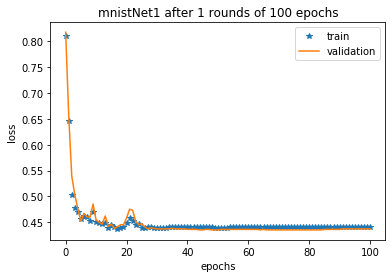

In [105]:
fig, ax = plt.subplots(figsize=(6,4))

plt.plot(avg_train_loss,'*',label='train')
plt.plot(avg_val_loss, label='validation')

nb_epochs = avg_train_loss.shape[0]

ax.legend()
plt.title("{}".format(mnist.__class__.__name__ )+" after {} rounds".format(rounds)+" of {} epochs".format(nb_epochs-1))
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

# Auxiliary loss training functions

In [100]:
def train_aux_model(model, rounds, nb_epochs=100, batch_size=100, validation=True, verbose=False):
                
    nb_epochs_shown = 10
    
    criterion = nn.CrossEntropyLoss()
    aux_criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr = 1e-3)
    
    # tensors for averaging over the rounds
    times = torch.zeros(rounds)
    train_acc = torch.zeros(rounds)
    test_acc = torch.zeros(rounds)
    train_loss = torch.zeros(rounds, nb_epochs + 1)
    validation_loss = torch.zeros(rounds, nb_epochs + 1)
    
    for r in range(rounds):
        
        # new data
        train_input, train_target, train_classes, val_input, val_target, val_classes = generate_pair_sets(nb=1000)
        
        aux_target1 = train_classes[:,0]
        aux_target2 = train_classes[:,1]
        aux_val_target1 = val_classes[:,0]
        aux_val_target2 = val_classes[:,1]
        
        # reset weights
        model.apply(weight_reset) 
        
        t0 = time.time()

        for e in range(nb_epochs):
            
            # store the train and validation loss for each epoch and round 
            if validation:
                model.train(False) # deactivate dropout
                train_loss[r,e] = criterion(model(train_input)[0], train_target)
                validation_loss[r,e] = criterion(model(val_input)[0], val_target)
                model.train(True) # activate dropout
            
            # updating the model
            for inputs, targets, aux_targets1, aux_targets2 in zip(train_input.split(batch_size), 
                                               train_target.split(batch_size), 
                                               aux_target1.split(batch_size),
                                               aux_target2.split(batch_size)):
                
                
                
                
                output1, aux_output1, aux_output2 = model(inputs)
                loss = criterion(output1, targets)
                loss_aux1 = aux_criterion(aux_output1,aux_targets1)
                loss_aux2 = aux_criterion(aux_output2,aux_targets2)
                
                c_loss = 0#1-torch.exp(-torch.tensor([float(e)])).item()
                c_aux = 1#torch.exp(-torch.tensor([float(e)])).item()
                
                loss =  c_loss * loss + c_aux*(loss_aux1 + 0*loss_aux2)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # print the loss for a given number of epochs - used for direct feedback
            if verbose:
                if((e + 1) % int(nb_epochs / nb_epochs_shown) == 0):
                    print("Epoch {} | Train loss : {}".format(e+1, loss))
                    
        # final loss            
        if validation:
            model.train(False) # deactivate dropout
            train_loss[r,nb_epochs] = criterion(model(train_input)[0], train_target)
            validation_loss[r,nb_epochs] = criterion(model(val_input)[0], val_target)
            model.train(True) # activate dropout

        t1 = time.time()
        
        times[r] = t1-t0
        train_acc[r] = accuracy(model, train_input, train_target)
        test_acc[r] = accuracy(model, val_input, val_target)
        
        print('Round {} done.'.format(r))
        
    print('--------------')
    
    total_trained_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("Model : {} \n".format(model.__class__.__name__ ) + \
          "Number of trained parameters : {} \n".format(total_trained_params) + \
          "Size of mini-batches : {}\n".format(batch_size) + \
          "Averaged on {} rounds \n".format(rounds) + \
          "    Time for {} epochs : {:.2f}s\n".format(nb_epochs, times.mean().item()) + \
          "    Train accuracy : {:.3f} \n".format(train_acc.mean().item()) + \
          "    Test accuracy : {:.3f}".format(test_acc.mean().item()))
    
    return train_loss.detach().mean(dim=0), validation_loss.detach().mean(dim=0)

# Auxiliary Nets

In [101]:
class AuxNet1(nn.Module):
    def __init__(self):
        super(AuxNet1,self).__init__()
        
        # Convolve
        self.conv1 = nn.Conv2d(1,16,kernel_size=4,padding=1,stride=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3,padding=0,stride=1)
        self.conv2 = nn.Conv2d(16,64,kernel_size=2,padding=0,stride=1)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2,padding=0,stride=2)
        self.conv3 = nn.Conv2d(64,128,kernel_size=1,padding=0,stride=1)
        self.conv4 = nn.Conv2d(128,64,kernel_size=2,padding=0,stride=1)
        self.conv5 = nn.Conv2d(64,16,kernel_size=3,padding=0,stride=1)
        self.fct = nn.Linear(64,10)
        
        # Recombine
        self.fc1 = nn.Linear(20,32)
        self.fc2 = nn.Linear(32,64)
        self.fc3 = nn.Linear(64,2)
    def Convolve(self,x):
        x = self.conv1(x)
        x = F.relu(x) # 16x13x13
        x = self.maxpool1(x)
        x = F.relu(x) # 16x11x11
        x = self.conv2(x)
        x = F.relu(x) # 64x10x10
        x = self.maxpool2(x)
        x = F.relu(x) # 64x5x5
        x = self.conv3(x)
        x = F.relu(x) # 128x5x5
        x = self.conv4(x)
        x = F.relu(x) # 64x4x4
        x = self.conv5(x)
        x = F.relu(x) # 16x2x2
        x = self.fct(x.view(-1,64))
        return x
    
    def DeterministicRecombine(self,x1,x2):
        nb_samples = x1.size(0)
        x = torch.zeros(nb_samples,2)
        for i in range(nb_samples):
            _,j = x1[i].max(0)
            _,k = x2[i].max(0)
            
            if j.item()<k.item():
                x[i,1]=1
            else:
                x[i,0]=1
        return x
    
    def NetworkRecombine(self,x1,x2):
        x = torch.cat((x1,x2),1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
        
    def forward(self,x): # 1x14x14
        
        x1 = self.Convolve(x[:,0:1])
        x2 = self.Convolve(x[:,1:2])
        
        x = self.DeterministicRecombine(x1,x2)
        #x = self.NetworkRecombine(x1,x2)
        
        return x, x1, x2

In [104]:
rounds = 1
aux_model = AuxNet1()
avg_train_loss, avg_val_loss = train_aux_model(aux_model, rounds,nb_epochs=100, validation=True, verbose=True)

Epoch 10 | Train loss : 0.04952908679842949
Epoch 20 | Train loss : 0.1029079407453537
Epoch 30 | Train loss : 0.000630632508546114
Epoch 40 | Train loss : 0.0002899112005252391
Epoch 50 | Train loss : 0.00016628489538561553
Epoch 60 | Train loss : 0.00011416320921853185
Epoch 70 | Train loss : 8.395621262025088e-05
Epoch 80 | Train loss : 6.432383088395e-05
Epoch 90 | Train loss : 5.01174436067231e-05
Epoch 100 | Train loss : 4.019885454908945e-05
Round 0 done.
--------------
Model : AuxNet1 
Number of trained parameters : 58380 
Size of mini-batches : 100
Averaged on 1 rounds 
    Time for 100 epochs : 140.35s
    Train accuracy : 0.873 
    Test accuracy : 0.876


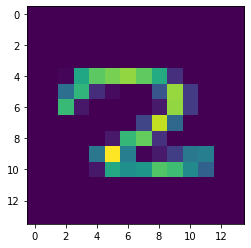

In [108]:
plt.imshow(train_input[0,0])